In [74]:
import final_project_fixed as fpf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

tickers = [fpf.UNDERLYING] + fpf.LETF_LIST + fpf.VIX_TICKERS

# Data
dfs = fpf.ensure_prices(tickers, fpf.START, fpf.END)
prices = fpf.align_adj_close({k: v for k, v in dfs.items() if not k.startswith('^')})
vix = fpf.align_adj_close({k: v for k, v in dfs.items() if k.startswith('^')})

all_dates = prices.index.intersection(vix.index)
prices = prices.loc[all_dates]
vix = vix.loc[all_dates]

In [75]:
vix_slope = (vix['^VIX3M'] - vix['^VIX']).rename('vix_slope')

In [76]:
rts = (np.log(prices[fpf.UNDERLYING]) / np.log(prices[fpf.UNDERLYING].shift(1)) - 1).rename('rts')

In [ ]:
rts_and_slope = rts.rolling(window=22).std().mul(np.sqrt(252)).rename('vol').to_frame().join(vix_slope).join(
    rts.shift(-22).rolling(window=22).std().mul(np.sqrt(252)).rename('vol_fwd')
).dropna()
rts_and_slope.index.name = 'date'
rts_and_slope.reset_index(inplace=True)

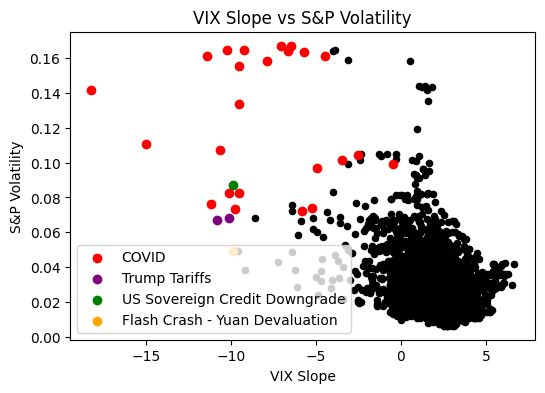

In [115]:
ax = rts_and_slope.plot(kind='scatter', x='vix_slope', y='vol_fwd', color='black', title='VIX Slope vs S&P Volatility', figsize=(6, 4))
ax.set_xlabel('VIX Slope')
ax.set_ylabel('S&P Volatility')

covid_mask = ((rts_and_slope['date'] >= '2020-02-27') & (rts_and_slope['date'] <= '2020-03-31'))
trump_tariffs_mask = ((rts_and_slope['date'] >= '2025-04-07') & (rts_and_slope['date'] <= '2025-04-08'))
sovereign_credit_mask = ((rts_and_slope['date'] >= '2011-08-08') & (rts_and_slope['date'] <= '2011-08-08'))
yuan_devaluation = ((rts_and_slope['date'] >= '2015-08-24') & (rts_and_slope['date'] <= '2015-08-24'))


ax.scatter(rts_and_slope.loc[covid_mask, 'vix_slope'], rts_and_slope.loc[covid_mask, 'vol_fwd'], color='red', label='COVID')
ax.scatter(rts_and_slope.loc[trump_tariffs_mask, 'vix_slope'], rts_and_slope.loc[trump_tariffs_mask, 'vol_fwd'], color='purple', label='Trump Tariffs')
ax.scatter(rts_and_slope.loc[sovereign_credit_mask, 'vix_slope'], rts_and_slope.loc[sovereign_credit_mask, 'vol_fwd'], color='green', label='US Sovereign Credit Downgrade')
ax.scatter(rts_and_slope.loc[sovereign_credit_mask, 'vix_slope'], rts_and_slope.loc[yuan_devaluation, 'vol_fwd'], color='orange', label='Flash Crash - Yuan Devaluation')

ax.legend()


In [85]:
vix_slope.sort_values().head(20)

Date
2020-03-12   -18.230000
2020-03-16   -14.990005
2020-03-09   -11.410000
2020-03-26   -11.209999
2025-04-08   -10.830002
2020-03-17   -10.640007
2020-02-28   -10.260000
2020-03-25   -10.100002
2025-04-07   -10.099998
2011-08-08    -9.900002
2020-03-27    -9.790001
2015-08-24    -9.600002
2020-03-24    -9.559998
2020-03-11    -9.530003
2020-03-13    -9.520000
2020-02-27    -9.240000
2018-02-05    -9.190001
2025-04-04    -8.600002
2020-03-10    -7.860001
2018-12-24    -7.230000
Name: vix_slope, dtype: float64